In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
valid_labels = pd.read_csv('../../../results/translation_efficiency/training_data/1_absolute/valid.tsv', sep='\t')
test_labels = pd.read_csv('../../../results/translation_efficiency/training_data/1_absolute/test.tsv', sep='\t')

In [3]:
model_dict = [
    ('pcv2_1', 'pcv2-l24-d0768'),
    ('pcv2_2', 'pcv2-l48-d1024'),
    ('pcv2_3', 'pcv2-l48-d1536'),
    ('agront', 'agront'),
    ('sup_pcv2_1', 'sup_pcv2-l24-d0768'),
    ('cnn_lstm', 'cnn_lstm'),
]

In [4]:
for model in model_dict:
    curPATH = f'../../../results/translation_efficiency/training_data/1_absolute/models/{model[1]}/valid_predictions.tsv'
    curPreds = pd.read_csv(curPATH, sep='\t')
    valid_labels[f'{model[0]}'] = curPreds['predicted_value']

In [5]:
for model in model_dict:
    curPATH = f'../../../results/translation_efficiency/training_data/1_absolute/models/{model[1]}/predictions.tsv'
    curPreds = pd.read_csv(curPATH, sep='\t')
    test_labels[f'{model[0]}'] = curPreds['predicted_value']

In [6]:
valid_labels.head()

,gene,chr,strand,TPM,seq,label,pcv2_1,pcv2_2,pcv2_3,agront,sup_pcv2_1,cnn_lstm
0,AT1G01030,1,-,1.088918,ATATACATATATAGTTTTCTTCCGATTCTAGGGTTTTCATATTTCC...,0.319921,0.622919,0.486662,0.449870,0.693786,0.687612,0.874281
1,AT1G01070,1,-,5.516785,ATAAAAAATTAAAGGGTGTAGTATGAAGTGCTTGATTAACTTTTCA...,0.814033,0.557520,0.440811,0.500158,0.515266,0.601815,0.381607
2,AT1G01100,1,-,323.478734,TAAATATGTCAAATGAAGAATTATGTTACTAGTGCGAAAAGGACAT...,2.511186,1.224231,1.302977,1.600904,1.182200,0.833963,0.955004
3,AT1G01120,1,-,95.581248,ATTAACAAGTTATGTTGTTTATCAAAAACTTCAAAAAAAAAAAAAA...,1.984893,0.967700,0.721050,0.833954,0.691851,0.635268,0.561094
4,AT1G01200,1,-,2.641557,TGGAGCATAAGAGCTTTTTTAGGTGGTCTCCAGACAAATCGTGGGT...,0.561287,1.021415,0.706845,0.932936,1.007687,0.852822,0.937034


In [7]:
records = []
pcv2_alphas = [0.4, 0.7, 1.0]
for k, model in enumerate(model_dict):
    valid_preds = valid_labels[f'{model[0]}']
    test_preds = test_labels[f'{model[0]}']

    valid_true = valid_labels['label']
    test_true = test_labels['label']
    
    scc_valid = valid_labels['label'].corr(valid_labels[f'{model[0]}'], method='spearman')
    scc_test = test_labels['label'].corr(test_labels[f'{model[0]}'], method='spearman')

    pcc_valid = valid_labels['label'].corr(valid_labels[f'{model[0]}'], method='pearson')
    pcc_test = test_labels['label'].corr(test_labels[f'{model[0]}'], method='pearson')
    

    if 'agront' in model[0].lower():
        color, alpha = 'gray', 1.0
    elif 'sup_pcv2' in model[0].lower():
        color, alpha = 'C1', 1.0
    elif 'cnn' in model[0].lower():
        color, alpha = 'C1', 0.5
    else:
        color, alpha = 'C0', pcv2_alphas[k]

    if 'cnn' in model[0].lower():
        lab = model[0].replace('-imbalance-lr-1e-3', '')
    else:
        lab = model[0].replace('', '')

    records.append({
        'model': model[0],
        'label': 'valid',
        'scc': scc_valid,
        'pcc': pcc_valid,
        'color': color,
        'alpha': alpha    })
    records.append({
        'model': model[0],
        'label': 'test',
        'scc': scc_valid,
        'pcc': pcc_valid,
        'color': color,
        'alpha': alpha    })

In [8]:
df = pd.DataFrame(records)
df.head()

,model,label,scc,pcc,color,alpha
0,pcv2_1,valid,0.468511,0.429029,C0,0.4
1,pcv2_1,test,0.468511,0.429029,C0,0.4
2,pcv2_2,valid,0.470192,0.431128,C0,0.7
3,pcv2_2,test,0.470192,0.431128,C0,0.7
4,pcv2_3,valid,0.540563,0.525120,C0,1.0


In [9]:
df.to_csv('auc_te-abs.tsv', sep='\t', index=False)

In [10]:
models = df['model'].unique()
n_models = len(models)

species_order = ['valid', 'test']
n_sp = len(species_order)

bar_w = 0.8 / n_models
x = np.arange(n_sp)

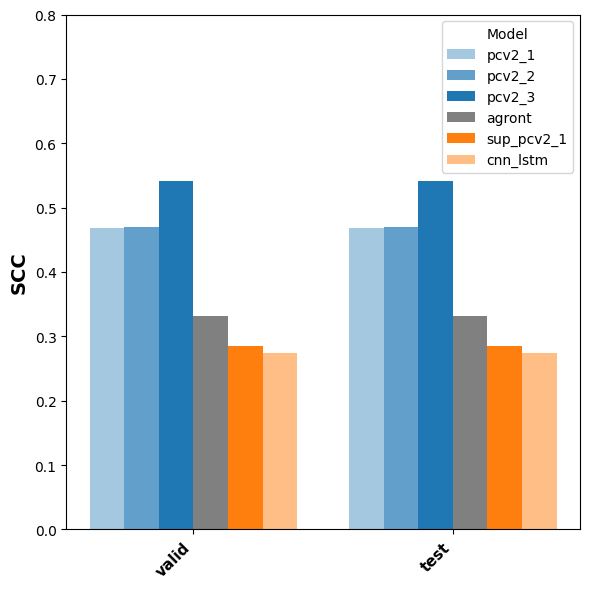

In [11]:
fig, ax = plt.subplots(figsize=(5 + 0.5 * n_sp, 6))

for i, model in enumerate(models):
    sub = df[df['model'] == model]
    sub = sub.set_index('label').reindex(species_order).reset_index()

    ax.bar(
        x + i * bar_w,
        sub['scc'],
        bar_w,
        label=model,
        color=sub['color'].iloc[0] if not sub.empty else 'gray',
        alpha=sub['alpha'].iloc[0] if not sub.empty else 0.5
    )

ax.set_xticks(x + bar_w * (n_models - 1) / 2)
ax.set_xticklabels(species_order, rotation=45, ha='right', fontsize=11, fontweight='bold')

ax.set_ylabel('SCC', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.legend(title='Model', fontsize=10)

plt.tight_layout()
plt.savefig('auc_te-abs.pdf', format='pdf', bbox_inches='tight')
plt.show()